# About the Dataset 
This dataset was taken from Kaggle provided by the Specialized Center for Endocrinology and Diabetes at Al-Kindy Teaching Hospital in Iraq. The dataset features 14 features and 800 observations. Features are medical metrics relevant to diabetes diagnosis; like age, bmi, cholesterol, etc. The observations are categorized by a binary classification of diabetic and not-diabetic.  

## Data Loading and Setup
Imported the data to the project and converted to a dataframe.


In [120]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("aravindpcoder/diabetes-dataset")

# print("Path to dataset files:", path)

In [121]:
# import shutil
# import os

# source_path = r"C:\Users\siver\.cache\kagglehub\datasets\aravindpcoder\diabetes-dataset\versions\1\Dataset of Diabetes .csv"

# destination_dir = os.getcwd()

# shutil.move(source_path, destination_dir)

# print(f"File moved to {destination_dir}")

In [122]:
import pandas as pd
df = pd.read_csv("Dataset of Diabetes .csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Exploring the Data
Viewed the shape of the data and checked the distribution of values.

In [123]:
df.shape

(1000, 14)

In [124]:
df.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [125]:
df.dtypes

ID             int64
No_Pation      int64
Gender        object
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS         object
dtype: object

In [126]:
df.describe() # Check distribution and range of values

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


## Evaluate Data
Our dataset was very clean and needed no real cleaning. Just removed some white space and converted the CLASS to a true binary value with a mapper function.

In [127]:
df['CLASS'].value_counts()

CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64

In [128]:
df = df[df['CLASS'] != 'P']
df

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,200,454317,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,671,876534,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,669,87654,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,99,24004,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


In [129]:
class_mapper = {
    'Y': 1,
    'N': 0
}

df['CLASS'] = df['CLASS'].str.strip() # Remove whitespace

df['CLASS'] = df['CLASS'].map(class_mapper) # Change to numerical values

df['CLASS'].value_counts()

CLASS
1    844
0    103
Name: count, dtype: int64

## Feature Engineering
This section we converted the string values to numerical values. Using a mapper function converted the Gender feature to numerical values, `0` being `male` and `1` being `female

In [130]:
df = df.drop(columns=['ID', 'No_Pation']) # Drop unneccessary columns

class_col = df.pop('CLASS') # Put target CLASS in first column
df.insert(0, 'CLASS', class_col)

df.head()

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,0,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
3,0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
4,0,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0


In [131]:
gender_mapper = {
    'M': 0,
    'F': 1
}

df['Gender'] = df['Gender'].str.strip().str.upper() # Remove whitespace, convert to uppercase

df['Gender'] = df['Gender'].map(gender_mapper) # Change to numerical values

df['Gender'].value_counts()

Gender
0    529
1    418
Name: count, dtype: int64

In [132]:
df.head()

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0,1,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,0,0,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,0,1,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
3,0,1,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
4,0,0,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0


In [133]:
df.info() # Check for missing values

<class 'pandas.core.frame.DataFrame'>
Index: 947 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CLASS   947 non-null    int64  
 1   Gender  947 non-null    int64  
 2   AGE     947 non-null    int64  
 3   Urea    947 non-null    float64
 4   Cr      947 non-null    int64  
 5   HbA1c   947 non-null    float64
 6   Chol    947 non-null    float64
 7   TG      947 non-null    float64
 8   HDL     947 non-null    float64
 9   LDL     947 non-null    float64
 10  VLDL    947 non-null    float64
 11  BMI     947 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 96.2 KB


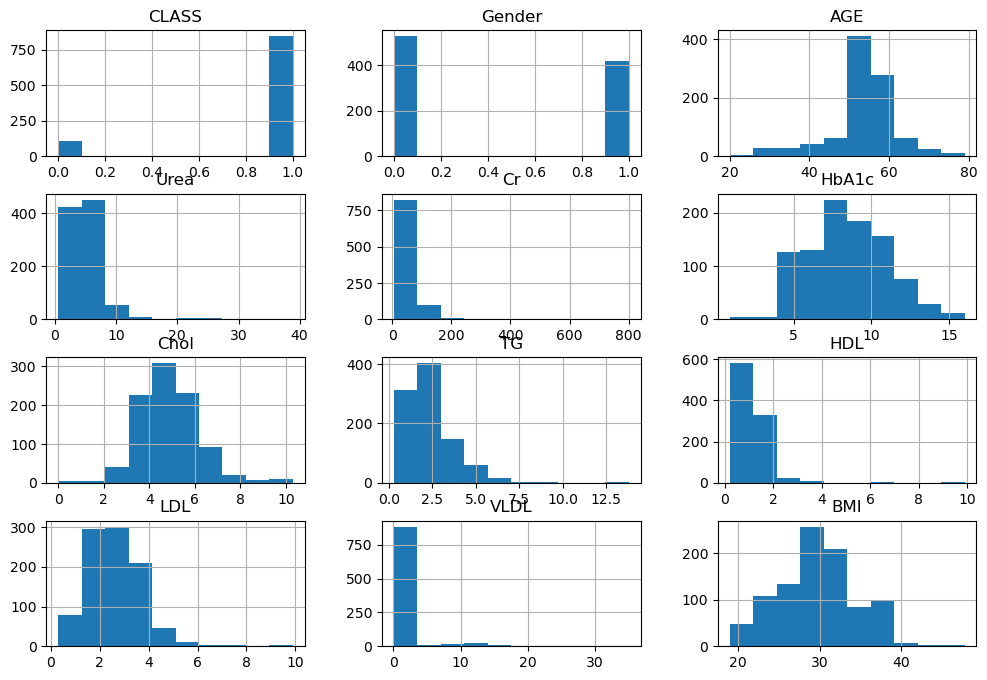

In [134]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 8)) # Check distributions
plt.show()

<Axes: >

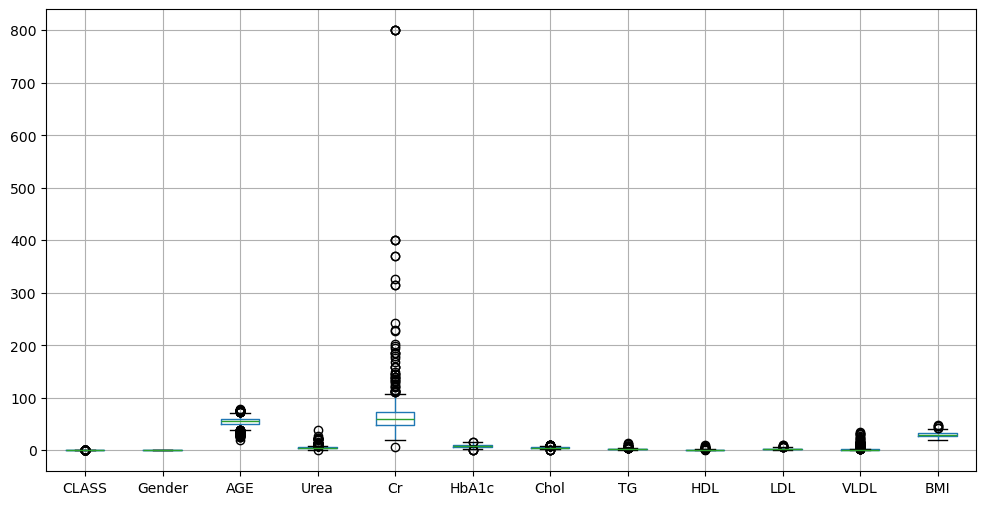

In [135]:
df.boxplot(figsize=(12, 6)) # Check for outliers

In [136]:
df['Cr'].sort_values(ascending=False).head()

860    800
283    800
273    800
846    800
589    401
Name: Cr, dtype: int64

In [137]:
df[df['Cr'] == 800]

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
273,1,0,58,20.8,800,9.1,6.6,2.9,1.1,4.3,1.3,33.0
283,1,0,58,20.8,800,9.1,6.6,2.9,1.1,4.3,1.3,33.0
846,1,0,56,20.8,800,9.0,4.6,2.0,1.2,2.5,0.9,35.0
860,1,0,60,20.8,800,9.0,2.3,1.1,0.9,0.9,0.5,33.0


In [138]:
df.columns[(df == 0).any()] # Checking columns that are measurements for zeros

Index(['CLASS', 'Gender', 'Chol'], dtype='object')

In [139]:
df.columns[(df == 0.0).any()]

Index(['CLASS', 'Gender', 'Chol'], dtype='object')

In [140]:
df[df['Chol'] == 0.0] # removing zeros in Chol, can't have zero cholesterol

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
99,0,0,77,5.0,106,5.4,0.0,2.8,0.8,1.8,0.7,19.0


In [141]:
df = df.drop(index=99)
df[df['Chol'] == 0.0]

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI


## Select and Train Model
We chose sklearn's LogisticRegression as our model. Training size is 80%, test and validation sets were 10% each. We maintained a stratified sample to help with class imbalance.

In [142]:
import numpy as np
from sklearn.model_selection import train_test_split
train, test_and_validate = train_test_split(df, test_size=0.2, random_state=42, stratify=df['CLASS'])

In [143]:
test, validate = train_test_split(test_and_validate, test_size=0.5, random_state=42, stratify=test_and_validate['CLASS'])

In [144]:
print(train.shape)
print(test.shape)
print(validate.shape)

(756, 12)
(95, 12)
(95, 12)


In [145]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

# Separate features and target
X_train = train.drop(columns='CLASS')
y_train = train['CLASS']

X_validate = validate.drop(columns='CLASS')
y_validate = validate['CLASS']

X_test = test.drop(columns='CLASS')
y_test = test['CLASS']

# Scale features using only training data
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validate_scaled = scaler.transform(X_validate)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(random_state=42, max_iter=1000) # Maximum iterations set higher because scaling is used
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [146]:
from sklearn.metrics import confusion_matrix

y_val_pred = model.predict(X_validate_scaled)

matrix = confusion_matrix(y_validate, y_val_pred)

df_confusion = pd.DataFrame(
    matrix,
    index=['Predicted Normal', 'Predicted Diabetes'],
    columns=['Actual Normal', 'Actual Diabetes']
)

df_confusion

,Actual Normal,Actual Diabetes
Predicted Normal,10,0
Predicted Diabetes,0,85


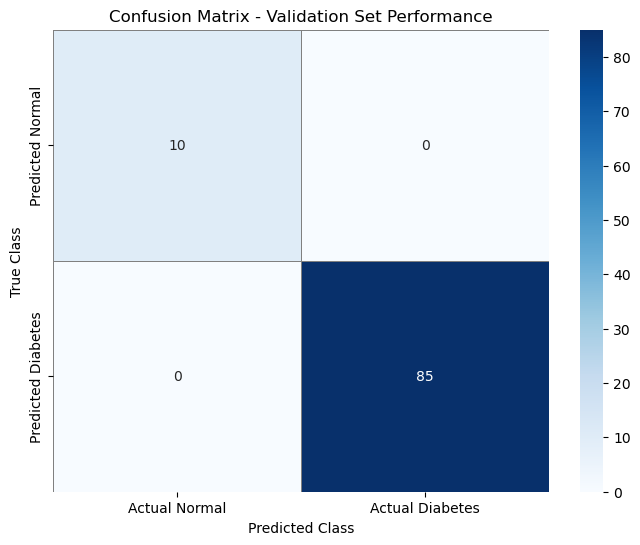

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_confusion, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            cbar=True,
            linewidths=.5,
            linecolor='gray') 

plt.title("Confusion Matrix - Validation Set Performance")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [148]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

TN, FP, FN, TP = confusion_matrix(y_validate, y_val_pred).ravel()

print(f"True Negative (TN) : {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP) : {TP}")

True Negative (TN) : 10
False Positive (FP): 0
False Negative (FN): 0
True Positive (TP) : 85


In [149]:
# Sensitivity, hit rate, recall, or true positive rate of validation set
Sensitivity  = float(TP)/(TP+FN)*100
print(f"Sensitivity or TPR: {Sensitivity}%")  
print(f"There is a {Sensitivity}% chance of detecting patients with diabetes to actually have diabetes")

Sensitivity or TPR: 100.0%
There is a 100.0% chance of detecting patients with diabetes to actually have diabetes


In [150]:
# Specificity or true negative rate of validation set
Specificity  = float(TN)/(TN+FP)*100
print(f"Specificity or TNR: {Specificity}%") 
print(f"There is a {Specificity}% chance of detecting non-diabetic patients as non-diabetic.")

Specificity or TNR: 100.0%
There is a 100.0% chance of detecting non-diabetic patients as non-diabetic.


In [151]:
# Precision or positive predictive value of validation set
Precision = float(TP)/(TP+FP)*100
print(f"Precision: {Precision}%")  
print(f"You have diabetes, and the probablity of that is  {Precision}%")

Precision: 100.0%
You have diabetes, and the probablity of that is  100.0%


In [152]:
# Negative predictive value of validation set
NPV = float(TN)/(TN+FN)*100
print(f"Negative Predictive Value: {NPV}%") 
print(f"You don't have a diabetes, but there is a {NPV}% chance that is incorrect" )

Negative Predictive Value: 100.0%
You don't have a diabetes, but there is a 100.0% chance that is incorrect


In [153]:
# Fall out or false positive rate of validation set
FPR = float(FP)/(FP+TN)*100
print( f"False Positive Rate: {FPR}%") 
print( f"There is a {FPR}% chance that this positive result is incorrect.")

False Positive Rate: 0.0%
There is a 0.0% chance that this positive result is incorrect.


In [154]:
# False negative rate of validation set
FNR = float(FN)/(TP+FN)*100
print(f"False Negative Rate: {FNR}%") 
print(f"There is a {FNR}% chance that this negative result is incorrect.")

False Negative Rate: 0.0%
There is a 0.0% chance that this negative result is incorrect.


In [155]:
# False discovery rate of validation set
FDR = float(FP)/(TP+FP)*100
print(f"False Discovery Rate: {FDR}%" )
print(f"You have diabetes, but there is a {FDR}% chance this is incorrect.")

False Discovery Rate: 0.0%
You have diabetes, but there is a 0.0% chance this is incorrect.


In [156]:
# Overall accuracy of validation set
ACC = float(TP+TN)/(TP+FP+FN+TN)*100
print(f"Accuracy: {ACC}%")

Accuracy: 100.0%


In [157]:
print(f"Sensitivity or TPR: {Sensitivity}%")    
print(f"Specificity or TNR: {Specificity}%") 
print(f"Precision: {Precision}%")   
print(f"Negative Predictive Value: {NPV}%")  
print( f"False Positive Rate: {FPR}%") 
print(f"False Negative Rate: {FNR}%")  
print(f"False Discovery Rate: {FDR}%" )
print(f"Accuracy: {ACC}%") 

Sensitivity or TPR: 100.0%
Specificity or TNR: 100.0%
Precision: 100.0%
Negative Predictive Value: 100.0%
False Positive Rate: 0.0%
False Negative Rate: 0.0%
False Discovery Rate: 0.0%
Accuracy: 100.0%


## Hyperparameter Tuning
The model performed perfectly on the validation set, for the sake of the machine learning pipeline hyperparameters are being optimized.

In [158]:
# Hyperparameter grid of different values
param_grid = [
    {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None},
    {'C': 0.1,  'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None},
    {'C': 1.0,  'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None},
    {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced'},
    {'C': 0.1,  'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced'},
    {'C': 1.0,  'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced'},
]

In [159]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
results = []

# Tune models with different parameters
for params in param_grid:
    model = LogisticRegression(
        C=params['C'],
        penalty=params['penalty'],
        solver=params['solver'],
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_val_pred = model.predict(X_validate_scaled)
    # Probability that class is 1
    y_val_prob = model.predict_proba(X_validate_scaled)[:, 1]

    # Results of tuning
    results.append({
        'C': params['C'],
        'penalty': params['penalty'],
        'solver': params['solver'],
        'val_accuracy': accuracy_score(y_validate, y_val_pred),
        'val_f1': f1_score(y_validate, y_val_pred),
        'val_auc': roc_auc_score(y_validate, y_val_prob)
    })

# Results DataFrame sorted by AUC, best values first
results_df = pd.DataFrame(results).sort_values(by='val_accuracy', ascending=False)
results_df

,C,penalty,solver,val_accuracy,val_f1,val_auc
1,0.10,l2,lbfgs,1.000000,1.000000,1.0
2,1.00,l2,lbfgs,1.000000,1.000000,1.0
5,1.00,l2,lbfgs,1.000000,1.000000,1.0
4,0.10,l2,lbfgs,1.000000,1.000000,1.0
0,0.01,l2,lbfgs,0.915789,0.955056,1.0
3,0.01,l2,lbfgs,0.915789,0.955056,1.0


In [160]:
# Train the model with the best hyperparameters
best_model = LogisticRegression(
    C=results_df.iloc[0]['C'],
    penalty=results_df.iloc[0]['penalty'],
    solver=results_df.iloc[0]['solver'],
    max_iter=1000,
    random_state=42
)

best_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0.1)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [161]:
y_test_pred = best_model.predict(X_test_scaled)

matrix = confusion_matrix(y_test, y_test_pred)

df_confusion = pd.DataFrame(
    matrix, 
    index=['Predicted Normal', 'Predicted Diabetes'],
    columns=['Actual Normal', 'Actual Diabetes']
)

df_confusion

,Actual Normal,Actual Diabetes
Predicted Normal,5,5
Predicted Diabetes,2,83


## Deploy the Model
Using the original model without parameters tuned because it performed perfectly.

In [162]:
from sklearn.metrics import confusion_matrix
import pandas as pd

y_test_pred = model.predict(X_test_scaled)

matrix = confusion_matrix(y_test, y_test_pred)

df_confusion = pd.DataFrame(
    matrix, 
    index=['Predicted Normal', 'Predicted Diabetes'],
    columns=['Actual Normal', 'Actual Diabetes']
)

df_confusion

,Actual Normal,Actual Diabetes
Predicted Normal,9,1
Predicted Diabetes,2,83


Graphed the Confusion Matrix

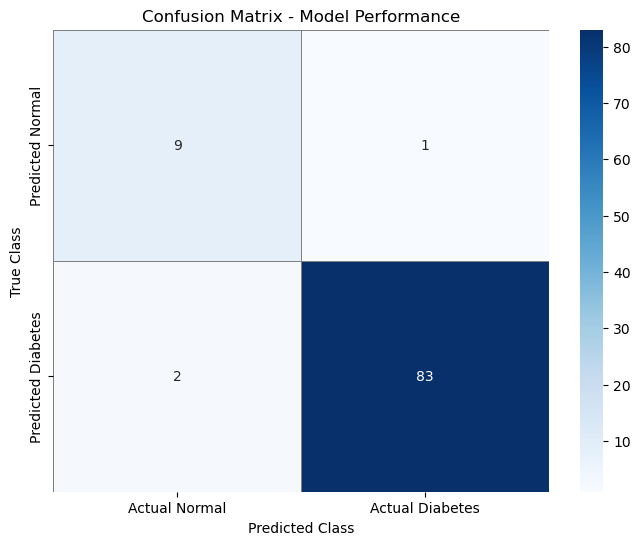

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_confusion, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            cbar=True,
            linewidths=.5,
            linecolor='gray') 

plt.title("Confusion Matrix - Model Performance")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

Extracted values from the Confusion Matrix

In [164]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

TN, FP, FN, TP = confusion_matrix(y_test, y_test_pred).ravel()

print(f"True Negative (TN) : {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP) : {TP}")

True Negative (TN) : 9
False Positive (FP): 1
False Negative (FN): 2
True Positive (TP) : 83


In [165]:
# Sensitivity, hit rate, recall, or true positive rate
Sensitivity  = float(TP)/(TP+FN)*100
print(f"Sensitivity or TPR: {Sensitivity}%")  
print(f"There is a {Sensitivity}% chance of detecting patients with diabetes to actually have diabetes")

Sensitivity or TPR: 97.6470588235294%
There is a 97.6470588235294% chance of detecting patients with diabetes to actually have diabetes


In [166]:
# Specificity or true negative rate
Specificity  = float(TN)/(TN+FP)*100
print(f"Specificity or TNR: {Specificity}%") 
print(f"There is a {Specificity}% chance of detecting non-diabetic patients as non-diabetic.")

Specificity or TNR: 90.0%
There is a 90.0% chance of detecting non-diabetic patients as non-diabetic.


In [167]:
# Precision or positive predictive value
Precision = float(TP)/(TP+FP)*100
print(f"Precision: {Precision}%")  
print(f"You have diabetes, and the probablity of that is  {Precision}%")

Precision: 98.80952380952381%
You have diabetes, and the probablity of that is  98.80952380952381%


In [168]:
# Negative predictive value
NPV = float(TN)/(TN+FN)*100
print(f"Negative Predictive Value: {NPV}%") 
print(f"You don't have a diabetes, but there is a {NPV}% chance that is incorrect" )

Negative Predictive Value: 81.81818181818183%
You don't have a diabetes, but there is a 81.81818181818183% chance that is incorrect


In [169]:
# Fall out or false positive rate
FPR = float(FP)/(FP+TN)*100
print( f"False Positive Rate: {FPR}%") 
print( f"There is a {FPR}% chance that this positive result is incorrect.")

False Positive Rate: 10.0%
There is a 10.0% chance that this positive result is incorrect.


In [170]:
# False negative rate
FNR = float(FN)/(TP+FN)*100
print(f"False Negative Rate: {FNR}%") 
print(f"There is a {FNR}% chance that this negative result is incorrect.")

False Negative Rate: 2.3529411764705883%
There is a 2.3529411764705883% chance that this negative result is incorrect.


In [171]:
# False discovery rate
FDR = float(FP)/(TP+FP)*100
print(f"False Discovery Rate: {FDR}%" )
print(f"You have diabetes, but there is a {FDR}% chance this is incorrect.")

False Discovery Rate: 1.1904761904761905%
You have diabetes, but there is a 1.1904761904761905% chance this is incorrect.


In [172]:
# Overall accuracy
ACC = float(TP+TN)/(TP+FP+FN+TN)*100
print(f"Accuracy: {ACC}%") 

Accuracy: 96.84210526315789%


In [173]:
print(f"Sensitivity or TPR: {Sensitivity}%")    
print(f"Specificity or TNR: {Specificity}%") 
print(f"Precision: {Precision}%")   
print(f"Negative Predictive Value: {NPV}%")  
print( f"False Positive Rate: {FPR}%") 
print(f"False Negative Rate: {FNR}%")  
print(f"False Discovery Rate: {FDR}%" )
print(f"Accuracy: {ACC}%") 

Sensitivity or TPR: 97.6470588235294%
Specificity or TNR: 90.0%
Precision: 98.80952380952381%
Negative Predictive Value: 81.81818181818183%
False Positive Rate: 10.0%
False Negative Rate: 2.3529411764705883%
False Discovery Rate: 1.1904761904761905%
Accuracy: 96.84210526315789%


### AUC-ROC

In [174]:
y_test = test.iloc[:,0]
print("Validation AUC", roc_auc_score(y_test, y_test_pred))

Validation AUC 0.9382352941176472


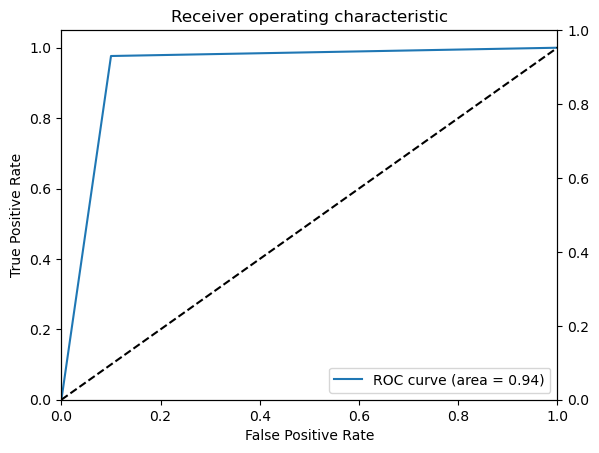

In [175]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming test_labels and target_predicted are defined

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % (roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ax2 = plt.gca().twinx()
# ax2.plot(fpr, thresholds, markeredgecolor='r', linestyle='dashed', color='r')
# ax2.set_ylabel('Threshold', color='r')
ax2.set_xlim([fpr[0], fpr[-1]])

plt.show()